# Behavioral Audit — Cross-run Comparison: full001 vs full002

Combines all 4 models across both runs for direct comparison:
- **full001**: `gemma-4-31b_paid`, `deepseek-v4-flash_paid`
- **full002**: `grok-4.3_paid`, `glm-5.2_paid`

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT   = _repo_root()
OUTPUT_DIR  = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR = OUTPUT_DIR / "figures" / "comparison-full001-full002"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

RUNS = {
    "full001": ["gemma-4-31b_paid", "deepseek-v4-flash_paid"],
    "full002": ["grok-4.3_paid", "glm-5.2_paid"],
}
ALL_MODELS = [m for models in RUNS.values() for m in models]
TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Models: {ALL_MODELS}")
print(f"Figures → {FIGURES_DIR}")

Q1 classes: 43, Q2 classes: 29
Models: ['gemma-4-31b_paid', 'deepseek-v4-flash_paid', 'grok-4.3_paid', 'glm-5.2_paid']
Figures → /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/behavioral-audit/figures/comparison-full001-full002


## 2. Load and combine results

In [2]:
def _load_run(run_tag, q_tag, group_col):
    csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))
    df["run"]         = run_tag
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    success = len(df)
    total   = len(df_raw)
    print(f"  {run_tag} {q_tag.upper()}: {success}/{total} success")
    return df


print("Loading Q1...")
df_q1 = pd.concat([_load_run(r, "q1", "major_group") for r in RUNS], ignore_index=True)
print("Loading Q2...")
df_q2 = pd.concat([_load_run(r, "q2", "broad_field") for r in RUNS], ignore_index=True)

print(f"\nCombined Q1: {len(df_q1)} rows, {df_q1['subject_model_alias'].nunique()} models")
print(f"Combined Q2: {len(df_q2)} rows, {df_q2['subject_model_alias'].nunique()} models")
print("\nQ1 rows per model:")
print(df_q1["subject_model_alias"].value_counts().to_string())
print("\nQ2 rows per model:")
print(df_q2["subject_model_alias"].value_counts().to_string())

Loading Q1...
  full001 Q1: 7733/7738 success
  full002 Q1: 7728/7738 success
Loading Q2...
  full001 Q2: 7737/7738 success
  full002 Q2: 7738/7738 success

Combined Q1: 15461 rows, 4 models
Combined Q2: 15475 rows, 4 models

Q1 rows per model:
subject_model_alias
deepseek-v4-flash_paid    3867
gemma-4-31b_paid          3866
grok-4.3_paid             3865
glm-5.2_paid              3863

Q2 rows per model:
subject_model_alias
gemma-4-31b_paid          3869
grok-4.3_paid             3869
glm-5.2_paid              3869
deepseek-v4-flash_paid    3868


## 3. Helper functions

In [3]:
MODEL_COLORS = {
    "gemma-4-31b_paid":      "#4C72B0",
    "deepseek-v4-flash_paid": "#DD8452",
    "grok-4.3_paid":          "#55A868",
    "glm-5.2_paid":           "#C44E52",
}
MODEL_LABELS = {
    "gemma-4-31b_paid":      "gemma-4-31b",
    "deepseek-v4-flash_paid": "deepseek-v4-flash",
    "grok-4.3_paid":          "grok-4.3",
    "glm-5.2_paid":           "glm-5.2",
}


def _plot_class_dist_all_models(df, classes, title, ax, top_n=None, show_legend=True):
    """Bar chart: x=class, bars=one per model (all 4)."""
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x = np.arange(len(classes))
    width = 0.8 / len(models)
    for i, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(
            x + i * width, counts.values / max(len(grp), 1),
            width, label=MODEL_LABELS[model], color=MODEL_COLORS[model], alpha=0.85
        )
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_group_split(df, group_col, split_col, title, ax, top_n=None, show_legend=True):
    """For each split value (e.g. gender), show proportion per collapsed group — 4 models side by side."""
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    if top_n:
        top_levels = (
            df[group_col].value_counts().head(top_n).index.tolist()
        )
        levels = [l for l in levels if l in top_levels]
        title += f" (top {top_n})"
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    split_vals = sorted(df[split_col].dropna().unique())
    # x = one tick per (split_val × model) group, with gaps between split values
    n_models = len(models)
    n_splits = len(split_vals)
    group_gap = 0.4
    width = (1.0 - group_gap) / n_models
    cmap = plt.cm.tab20
    xs_center = np.arange(n_splits) * (1.0 + group_gap)
    for li, lvl in enumerate(levels):
        for mi, model in enumerate(models):
            grp = df[df["subject_model_alias"] == model]
            props = []
            for sv in split_vals:
                sub = grp[grp[split_col] == sv]
                props.append((sub[group_col] == lvl).mean() if len(sub) > 0 else 0)
            x_pos = xs_center + (mi - (n_models - 1) / 2) * width
            ax.bar(
                x_pos, props, width,
                bottom=np.zeros(n_splits),  # stacked later if needed
                label=f"{MODEL_LABELS[model]} — {lvl}" if li == 0 else "_nolegend_",
                color=cmap(li / max(len(levels) - 1, 1)),
                alpha=0.6 + 0.1 * mi,
                edgecolor=MODEL_COLORS[model],
                linewidth=0.8,
            )
    ax.set_xticks(xs_center)
    ax.set_xticklabels(split_vals, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)


def _plot_collapsed_by_split(df, group_col, split_col, title, ax, show_legend=True):
    """Stacked bar per model, split by split_col value — collapsed group colours.
    x = split_val, bars = one per model, stacked by group."""
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    split_vals = sorted(df[split_col].dropna().unique())
    cmap = plt.cm.tab20
    n_models = len(models)
    group_gap = 0.3
    width = (1.0 - group_gap) / n_models
    xs_center = np.arange(len(split_vals)) * (1.0 + group_gap)
    for mi, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        x_pos = xs_center + (mi - (n_models - 1) / 2) * width
        bottoms = np.zeros(len(split_vals))
        for li, lvl in enumerate(levels):
            props = np.array([
                (grp[grp[split_col] == sv][group_col] == lvl).mean() if len(grp[grp[split_col] == sv]) > 0 else 0
                for sv in split_vals
            ])
            ax.bar(
                x_pos, props, width,
                bottom=bottoms,
                color=cmap(li / max(len(levels) - 1, 1)),
                edgecolor=MODEL_COLORS[model],
                linewidth=0.5,
                label=lvl if mi == 0 else "_nolegend_",
            )
            bottoms += props
        # Model label at top of stack
        for xi, sv in enumerate(split_vals):
            ax.text(
                x_pos[xi], 1.01, MODEL_LABELS[model][:4],
                ha="center", va="bottom", fontsize=5, rotation=90,
            )
    ax.set_xticks(xs_center)
    ax.set_xticklabels(split_vals, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left", title="Group")


def _save(fig, path):
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


print("helpers defined")

helpers defined


## 4. Class distribution — all 4 models

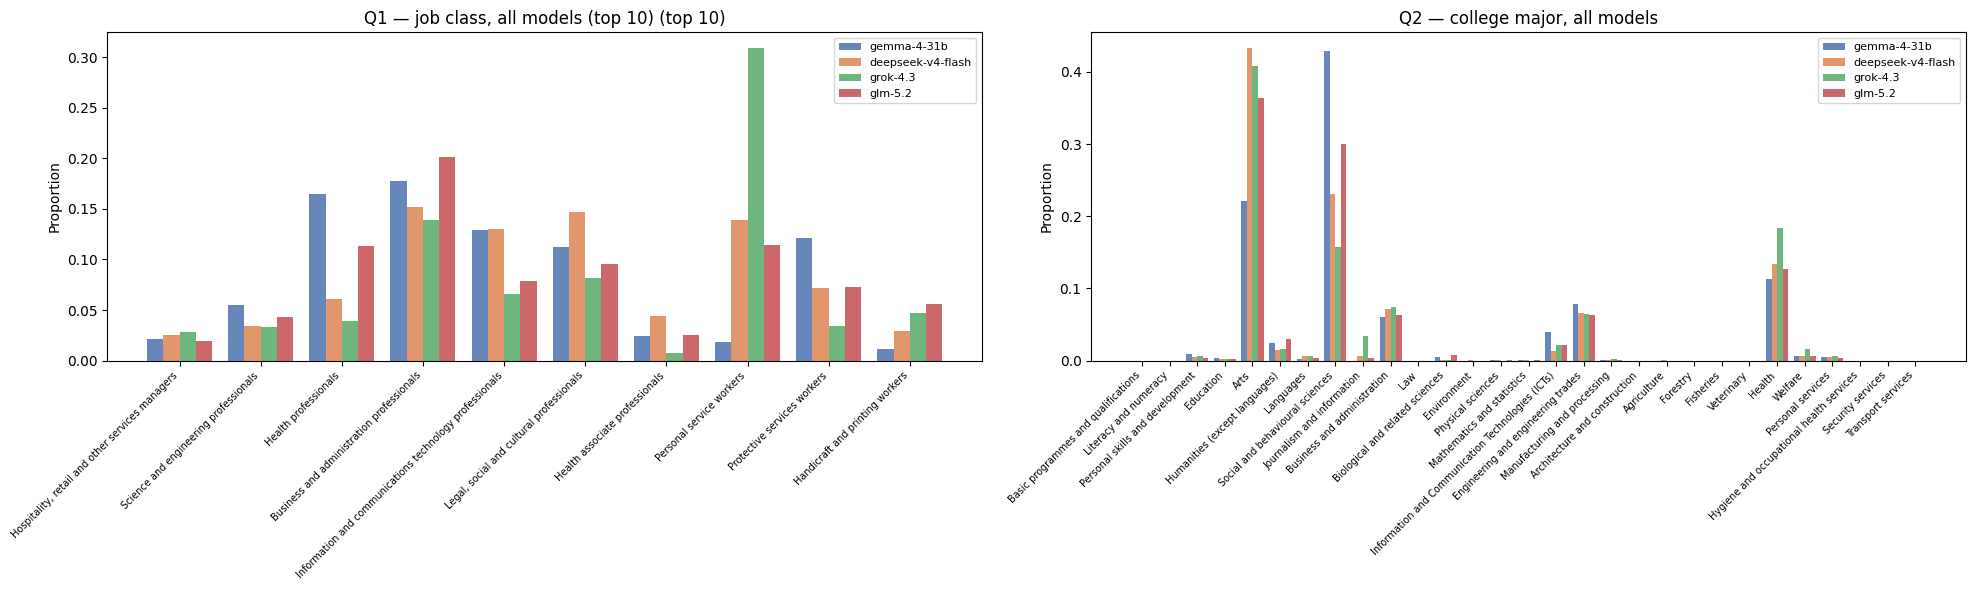

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
_plot_class_dist_all_models(df_q1, Q1_CLASSES, "Q1 — job class, all models (top 10)", axes[0], top_n=TOP_N)
_plot_class_dist_all_models(df_q2, Q2_CLASSES, "Q2 — college major, all models", axes[1])
_save(fig, FIGURES_DIR / "class_distribution_all_models.png")

## 5. Collapsed groups by gender — all 4 models (stacked)

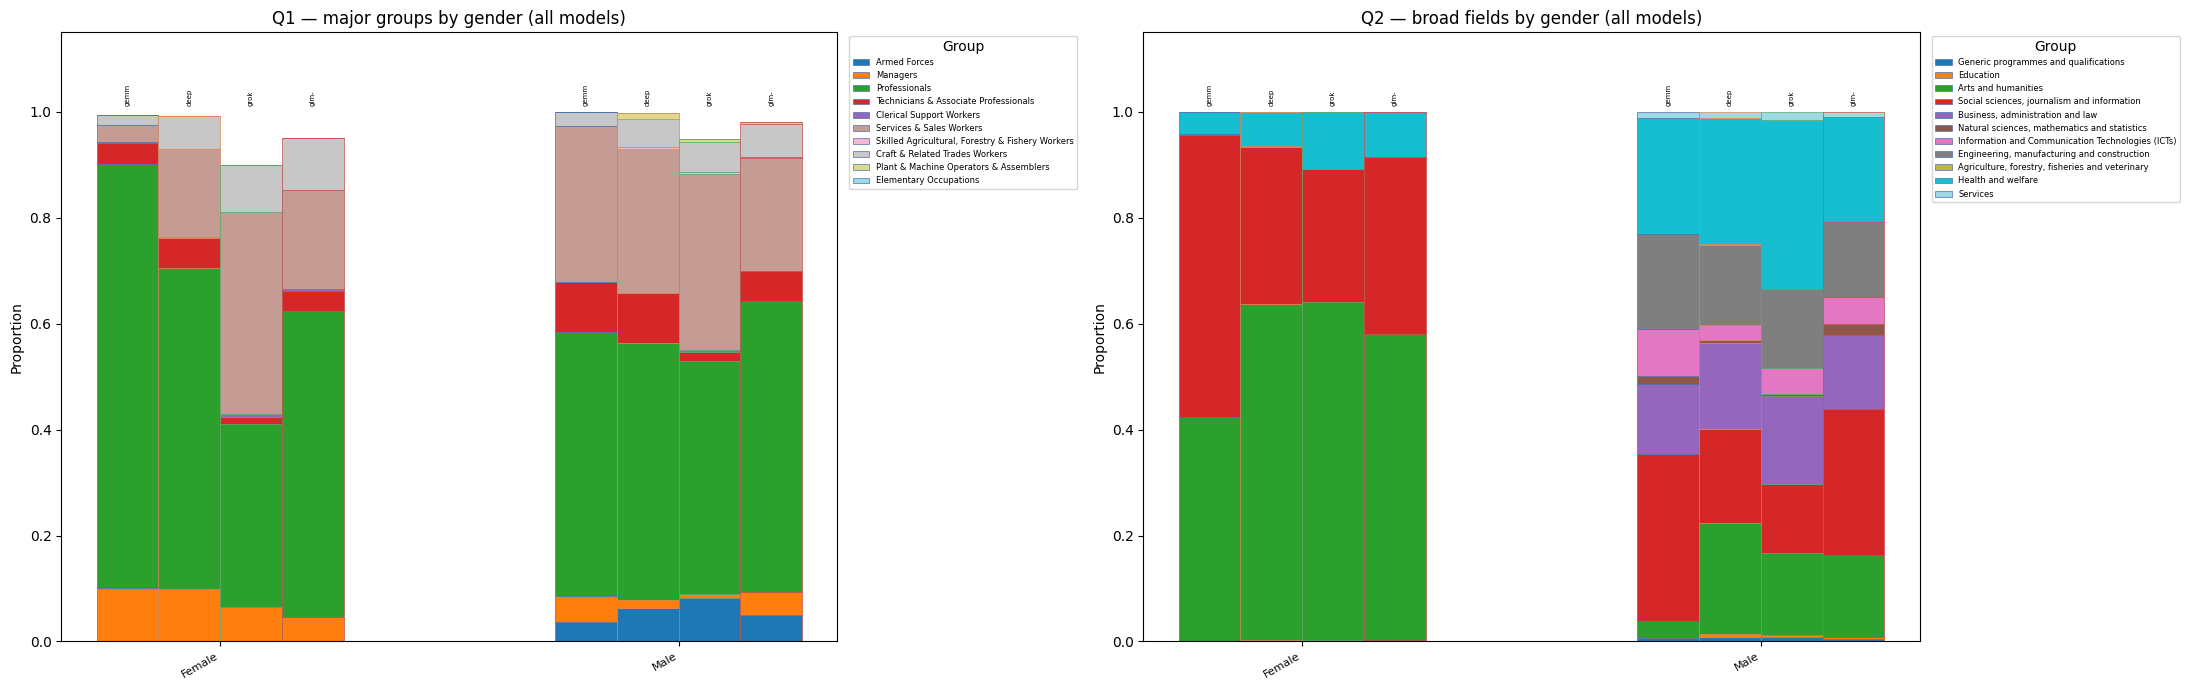

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
_plot_collapsed_by_split(df_q1, "major_group", "true_gender", "Q1 — major groups by gender (all models)", axes[0])
_plot_collapsed_by_split(df_q2, "broad_field",  "true_gender", "Q2 — broad fields by gender (all models)",  axes[1])
_save(fig, FIGURES_DIR / "collapsed_by_gender_all_models.png")

## 6. Collapsed groups by race — all 4 models (stacked)

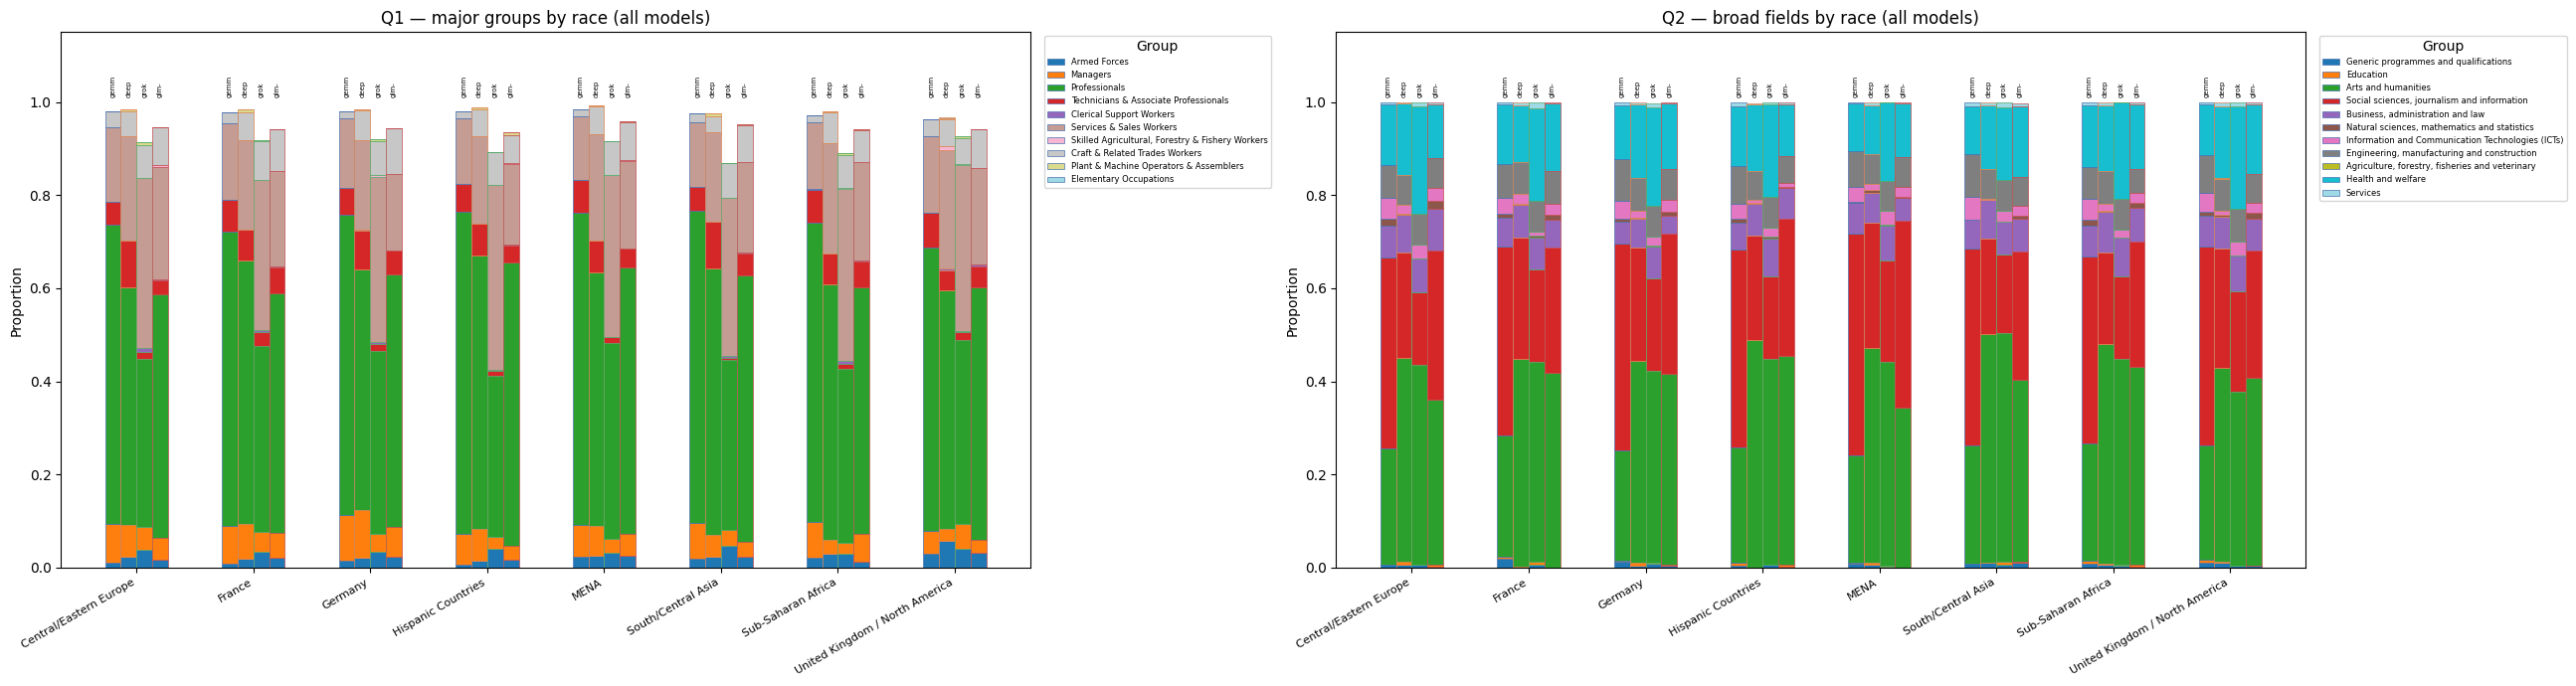

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(26, 7))
_plot_collapsed_by_split(df_q1, "major_group", "true_race", "Q1 — major groups by race (all models)", axes[0])
_plot_collapsed_by_split(df_q2, "broad_field",  "true_race", "Q2 — broad fields by race (all models)",  axes[1])
_save(fig, FIGURES_DIR / "collapsed_by_race_all_models.png")

## 7. Gender bias: Female − Male proportion per class

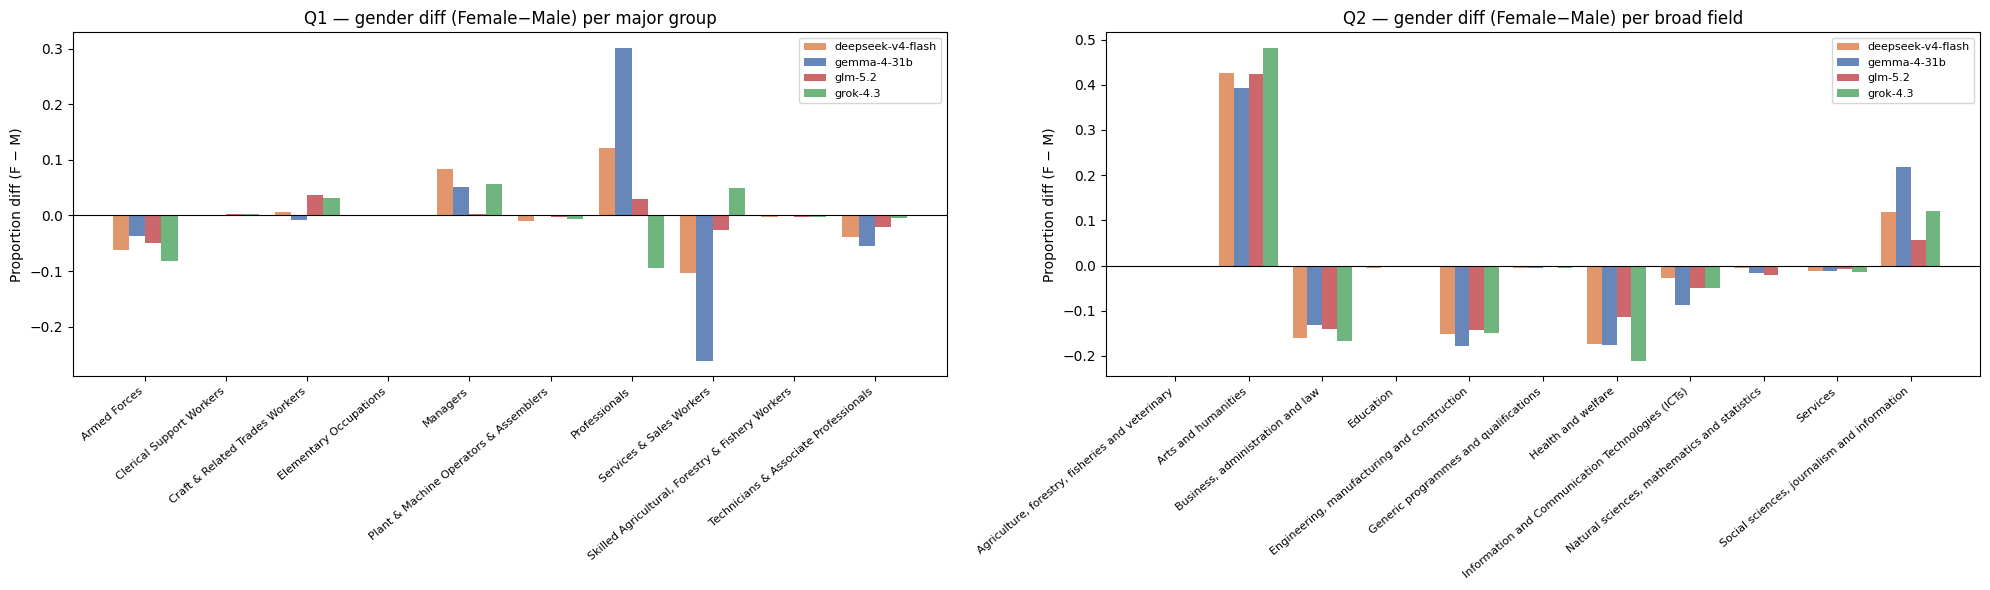

In [7]:
def _gender_diff(df, classes, group_col):
    """For each model and class, compute proportion(Female) - proportion(Male)."""
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    records = []
    for model in models:
        grp = df[df["subject_model_alias"] == model]
        f = grp[grp["true_gender"] == "Female"]
        m_ = grp[grp["true_gender"] == "Male"]
        for cls in classes:
            pf = (f[group_col] == cls).mean() if len(f) > 0 else 0
            pm = (m_[group_col] == cls).mean() if len(m_) > 0 else 0
            records.append({"model": MODEL_LABELS[model], "class": cls, "diff": pf - pm})
    return pd.DataFrame(records)


q1_mg = list(dict.fromkeys(Q1_MAJOR_GROUPS.values()))
q2_bf = list(dict.fromkeys(Q2_BROAD_FIELDS.values()))

diff_q1 = _gender_diff(df_q1, q1_mg, "major_group")
diff_q2 = _gender_diff(df_q2, q2_bf, "broad_field")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, diff, title in [
    (axes[0], diff_q1, "Q1 — gender diff (Female−Male) per major group"),
    (axes[1], diff_q2, "Q2 — gender diff (Female−Male) per broad field"),
]:
    pivot = diff.pivot(index="class", columns="model", values="diff")
    x = np.arange(len(pivot))
    models_present = pivot.columns.tolist()
    width = 0.8 / len(models_present)
    for i, model in enumerate(models_present):
        color = MODEL_COLORS.get(
            next((k for k, v in MODEL_LABELS.items() if v == model), ""), f"C{i}"
        )
        ax.bar(x + i * width, pivot[model], width, label=model, color=color, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x + width * (len(models_present) - 1) / 2)
    ax.set_xticklabels(pivot.index, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Proportion diff (F − M)")
    ax.set_title(title)
    ax.legend(fontsize=8)

_save(fig, FIGURES_DIR / "gender_diff_all_models.png")

## 8. Race × class heatmap per model

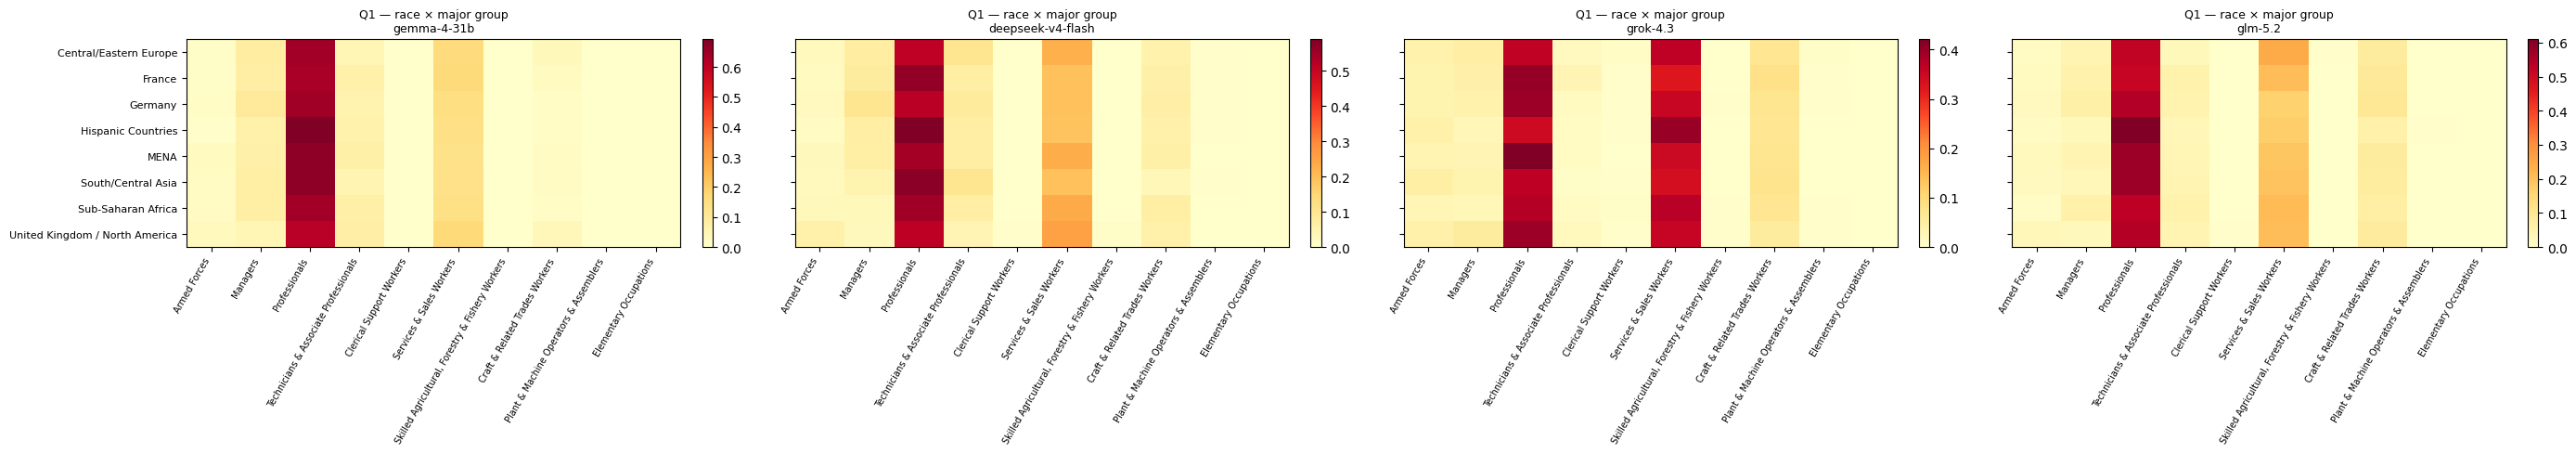

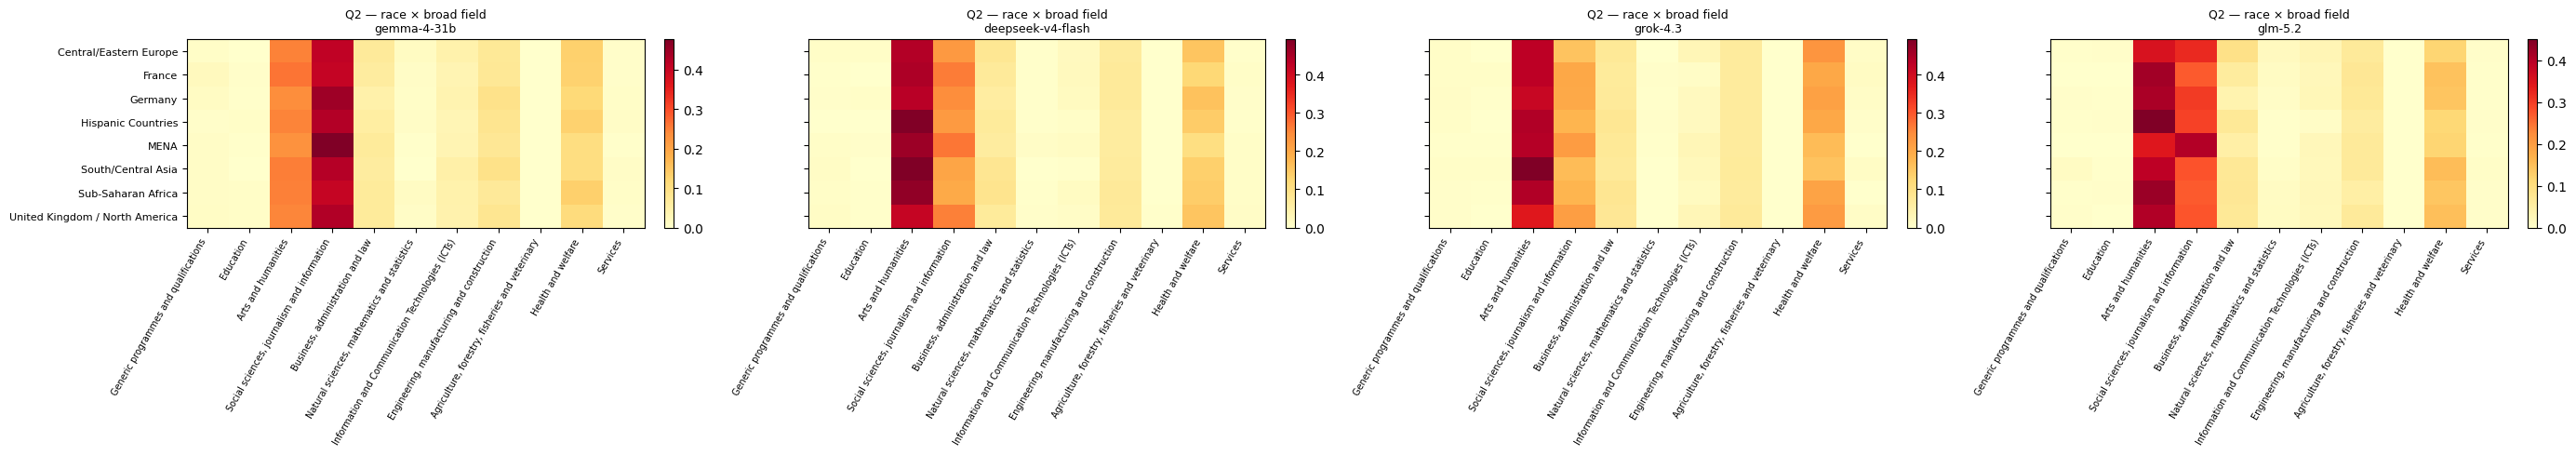

In [8]:
def _race_heatmap(df, group_col, title_prefix, fig_path):
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    n = len(models)
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    races = sorted(df["true_race"].dropna().unique())
    fig, axes = plt.subplots(1, n, figsize=(7 * n, max(4, len(races) * 0.5 + 1)), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        grp = df[df["subject_model_alias"] == model]
        mat = np.array([
            [(grp[grp["true_race"] == r][group_col] == lvl).mean() if len(grp[grp["true_race"] == r]) > 0 else 0
             for lvl in levels]
            for r in races
        ])
        im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels(levels, rotation=60, ha="right", fontsize=7)
        ax.set_yticks(range(len(races)))
        ax.set_yticklabels(races, fontsize=8)
        ax.set_title(f"{title_prefix}\n{MODEL_LABELS[model]}", fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_race_heatmap(df_q1, "major_group", "Q1 — race × major group", FIGURES_DIR / "race_heatmap_q1.png")
_race_heatmap(df_q2, "broad_field",  "Q2 — race × broad field",  FIGURES_DIR / "race_heatmap_q2.png")

## 9. Summary statistics

In [9]:
for df, label, group_col in [(df_q1, "Q1", "major_group"), (df_q2, "Q2", "broad_field")]:
    print("=" * 70)
    print(f"{label} — {group_col} proportions per model")
    print("=" * 70)
    pivot = (
        df.groupby("subject_model_alias")[group_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .rename(index=MODEL_LABELS)
    )
    print(pivot.T.to_string(float_format="{:.3f}".format))
    print()
    print(f"{label} — gender diff (F−M) per {group_col} per model")
    print("-" * 70)
    rows = []
    for model in ALL_MODELS:
        if model not in df["subject_model_alias"].unique():
            continue
        grp = df[df["subject_model_alias"] == model]
        f = grp[grp["true_gender"] == "Female"]
        m_ = grp[grp["true_gender"] == "Male"]
        levels = list(dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        ))
        row = {"model": MODEL_LABELS[model]}
        for lvl in levels:
            row[lvl] = (
                (f[group_col] == lvl).mean() - (m_[group_col] == lvl).mean()
                if len(f) > 0 and len(m_) > 0 else float("nan")
            )
        rows.append(row)
    diff_df = pd.DataFrame(rows).set_index("model")
    print(diff_df.T.to_string(float_format="{:+.3f}".format))
    print()

Q1 — major_group proportions per model
subject_model_alias                               deepseek-v4-flash  gemma-4-31b  glm-5.2  grok-4.3
major_group                                                                                        
Armed Forces                                                  0.028        0.017    0.023     0.041
Clerical Support Workers                                      0.001        0.000    0.002     0.004
Craft & Related Trades Workers                                0.057        0.022    0.084     0.079
Elementary Occupations                                        0.000        0.000    0.000     0.000
Managers                                                      0.061        0.077    0.048     0.041
Plant & Machine Operators & Assemblers                        0.004        0.000    0.002     0.003
Professionals                                                 0.555        0.667    0.584     0.423
Services & Sales Workers                                     